# 🔗 Mapeo entre Datasets: Enfermedades (EN) ↔ Urgencias (ES)

## Objetivo
Crear el puente entre ambos datasets:
- Mapear `DxSindromatico` (español) → vectores de síntomas binarios (inglés)
- Mapear enfermedades predichas (inglés) → `NombreDiagnostico` (español)
- Evaluar la cobertura del mapeo
- Generar el dataset combinado para el pipeline unificado

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import warnings

sys.path.insert(0, '..')
from src.config import SINDROMATIC_TO_SYMPTOMS, DISEASE_TO_DIAGNOSTICO, TRIAGE_EXCLUDE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✅ Librerías y configuración cargadas')

✅ Librerías y configuración cargadas


## 1. Cargar Ambos Datasets

In [2]:
# Dataset de enfermedades y síntomas
df_diseases = pd.read_csv('../insumos/Final_Augmented_dataset_Diseases_and_Symptoms.csv')
symptom_cols = df_diseases.columns[1:].tolist()

print(f'📊 Dataset Enfermedades: {df_diseases.shape}')
print(f'   Enfermedades: {df_diseases["diseases"].nunique()}, Síntomas: {len(symptom_cols)}')

# Dataset de urgencias
df_urgencias = pd.read_excel('../insumos/Morbilidad_urgencias_Hospital_Pitalito_20260406.xlsx')
df_urgencias = df_urgencias[~df_urgencias['Triage'].isin(TRIAGE_EXCLUDE)]

print(f'\n📊 Dataset Urgencias (limpio): {df_urgencias.shape}')
print(f'   Triaje: {sorted(df_urgencias["Triage"].unique())}')
print(f'   DxSindromatico únicos: {df_urgencias["DxSindromatico"].nunique()}')

📊 Dataset Enfermedades: (246945, 378)
   Enfermedades: 773, Síntomas: 377

📊 Dataset Urgencias (limpio): (59001, 21)
   Triaje: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   DxSindromatico únicos: 297


## 2. Mapeo DxSindromatico → Síntomas Binarios

In [3]:
# Verificar cobertura del mapeo
all_dx = df_urgencias['DxSindromatico'].unique()
mapped_dx = set(SINDROMATIC_TO_SYMPTOMS.keys())
covered = set(all_dx) & mapped_dx
uncovered = set(all_dx) - mapped_dx

# Calcular cobertura por número de registros
dx_counts = df_urgencias['DxSindromatico'].value_counts()
covered_records = sum(dx_counts[dx] for dx in covered if dx in dx_counts.index)
total_records = len(df_urgencias)

print(f'📊 Cobertura del Mapeo DxSindromatico → Síntomas')
print(f'   Diagnósticos mapeados: {len(covered)} de {len(all_dx)} ({len(covered)/len(all_dx)*100:.1f}%)')
print(f'   Registros cubiertos: {covered_records:,} de {total_records:,} ({covered_records/total_records*100:.1f}%)')
print(f'\n   Diagnósticos NO mapeados (top 20 más frecuentes):')
uncovered_sorted = [(dx, dx_counts.get(dx, 0)) for dx in uncovered]
uncovered_sorted.sort(key=lambda x: x[1], reverse=True)
for dx, count in uncovered_sorted[:20]:
    print(f'     - {dx}: {count:,} registros')

📊 Cobertura del Mapeo DxSindromatico → Síntomas
   Diagnósticos mapeados: 25 de 297 (8.4%)
   Registros cubiertos: 40,619 de 59,001 (68.8%)

   Diagnósticos NO mapeados (top 20 más frecuentes):
     - DOLOR LUMBAR SIN SINTOMAS ASOCIADOS: 629 registros
     - EPISODIO CONVULSION: 535 registros
     - TRAUMA CERRADO: 495 registros
     - DOLOR LUMBAR IRRADIADO Y PARESTESIAS: 490 registros
     - DOLOR OCULAR: 477 registros
     - VOMITO SIN SANGRE: 446 registros
     - OTALGIA OTORREA Y FIEBRE: 411 registros
     - AMIGDALITIS AGUDA: 402 registros
     - DOLOR TORACICO CON LA INSPIRACION: 382 registros
     - SINCOPE O LIPOTIMIA: 381 registros
     - HIPERTENSION O HIPOTENSION SEVERA: 349 registros
     - DISURIA, POLAQUIURIA, FIEBRE: 341 registros
     - ARTRALGIAS  FIEBRE: 327 registros
     - CUERPO EXTRAÑO EN EL OJO: 322 registros
     - DOLOR TORACICO CON LA PALPACION: 320 registros
     - EDEMA SIN TRAUMA: 317 registros
     - SINDROME EMETICO: 300 registros
     - FRACTURAS: 297 r

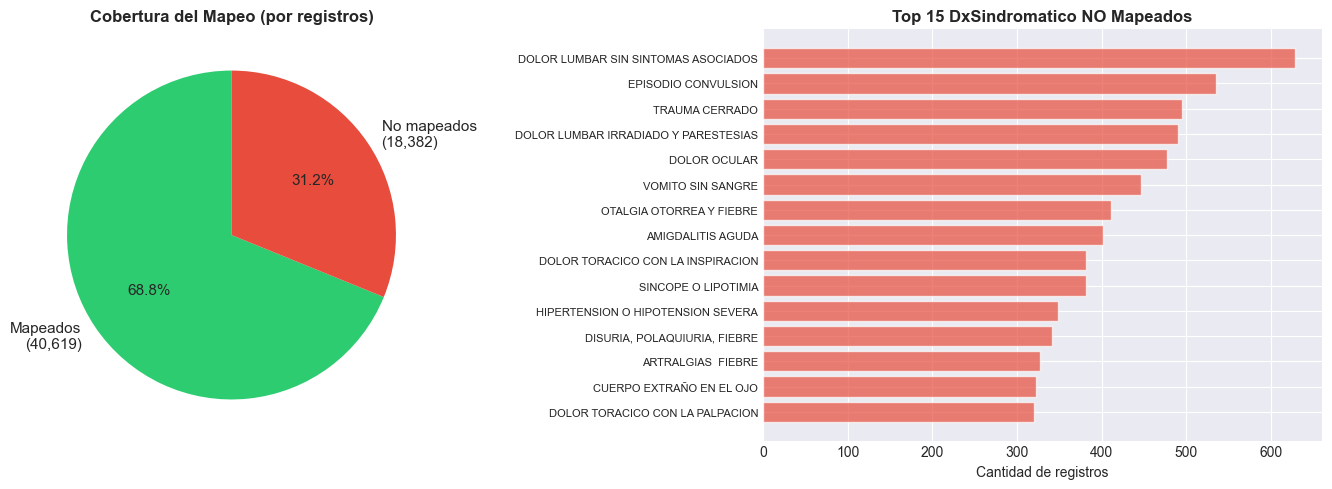

In [4]:
# Visualización de cobertura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart de cobertura
axes[0].pie([covered_records, total_records - covered_records], 
           labels=[f'Mapeados\n({covered_records:,})', f'No mapeados\n({total_records-covered_records:,})'],
           autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
           textprops={'fontsize': 11})
axes[0].set_title('Cobertura del Mapeo (por registros)', fontweight='bold')

# Top diagnósticos no mapeados
top_uncov = uncovered_sorted[:15]
if top_uncov:
    names = [u[0][:40] for u in top_uncov]
    vals = [u[1] for u in top_uncov]
    axes[1].barh(range(len(names)), vals, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[1].set_yticks(range(len(names)))
    axes[1].set_yticklabels(names, fontsize=8)
    axes[1].set_xlabel('Cantidad de registros')
    axes[1].set_title('Top 15 DxSindromatico NO Mapeados', fontweight='bold')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/03_cobertura_mapeo.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Función para convertir DxSindromatico a vector de síntomas
def dx_to_symptom_vector(dx_sindromatico, symptom_columns):
    """Convierte un DxSindromatico a un vector binario de síntomas."""
    vector = pd.Series(0, index=symptom_columns)
    
    if dx_sindromatico in SINDROMATIC_TO_SYMPTOMS:
        symptoms = SINDROMATIC_TO_SYMPTOMS[dx_sindromatico]
        for symptom in symptoms:
            if symptom in symptom_columns:
                vector[symptom] = 1
    
    return vector

# Ejemplo de mapeo
ejemplo_dx = 'CEFALEA Y FIEBRE'
vector_ejemplo = dx_to_symptom_vector(ejemplo_dx, symptom_cols)
symptoms_activos = vector_ejemplo[vector_ejemplo == 1].index.tolist()

print(f'📋 Ejemplo de mapeo:')
print(f'   DxSindromatico: "{ejemplo_dx}"')
print(f'   Síntomas activados: {symptoms_activos}')
print(f'   Total síntomas activos: {vector_ejemplo.sum()} de {len(symptom_cols)}')

📋 Ejemplo de mapeo:
   DxSindromatico: "CEFALEA Y FIEBRE"
   Síntomas activados: ['vomiting', 'headache', 'nausea', 'fever', 'ache all over']
   Total síntomas activos: 5 de 377


## 3. Verificar Mapeo de Síntomas contra Dataset de Enfermedades

In [6]:
# Verificar que todos los síntomas del mapeo existen en el dataset
all_mapped_symptoms = set()
for symptoms in SINDROMATIC_TO_SYMPTOMS.values():
    all_mapped_symptoms.update(symptoms)

symptoms_in_dataset = set(symptom_cols)
missing = all_mapped_symptoms - symptoms_in_dataset
valid = all_mapped_symptoms & symptoms_in_dataset

print(f'📊 Verificación de síntomas en el mapeo:')
print(f'   Total síntomas en mapeo: {len(all_mapped_symptoms)}')
print(f'   Existen en dataset: {len(valid)} ✅')
print(f'   NO existen en dataset: {len(missing)} ❌')
if missing:
    print(f'\n   Síntomas faltantes: {missing}')
    print(f'\n   📌 Estos síntomas serán ignorados en el mapeo.')

📊 Verificación de síntomas en el mapeo:
   Total síntomas en mapeo: 48
   Existen en dataset: 46 ✅
   NO existen en dataset: 2 ❌

   Síntomas faltantes: {'swelling', 'bleeding or discharge from wound'}

   📌 Estos síntomas serán ignorados en el mapeo.


## 4. Crear Dataset Combinado para el Pipeline

In [7]:
# Crear vectores de síntomas para todos los registros de urgencias con mapeo
df_mapped = df_urgencias[df_urgencias['DxSindromatico'].isin(SINDROMATIC_TO_SYMPTOMS.keys())].copy()

print(f'🔄 Generando vectores de síntomas para {len(df_mapped):,} registros...')

# Crear vectors
symptom_vectors = []
for dx in df_mapped['DxSindromatico']:
    vector = dx_to_symptom_vector(dx, symptom_cols)
    symptom_vectors.append(vector)

df_symptoms = pd.DataFrame(symptom_vectors, index=df_mapped.index)

# Combinar con datos de urgencias
df_combined = pd.concat([
    df_mapped[['Triage', 'DxSindromatico', 'NombreDiagnostico', 'Sexo', 'Edad', 'GrupoEtario1', 'Unidad']].reset_index(drop=True),
    df_symptoms.reset_index(drop=True)
], axis=1)

print(f'✅ Dataset combinado creado: {df_combined.shape}')
print(f'   Columnas: {len(df_combined.columns)} ({7} de urgencias + {len(symptom_cols)} de síntomas)')
df_combined.head()

🔄 Generando vectores de síntomas para 40,619 registros...
✅ Dataset combinado creado: (40619, 384)
   Columnas: 384 (7 de urgencias + 377 de síntomas)


,Triage,DxSindromatico,NombreDiagnostico,Sexo,Edad,GrupoEtario1,Unidad,anxiety and nervousness,depression,shortness of breath,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,3,CONTUSIONES,"HERIDA DE LA CABEZA, PARTE NO ESPECIFICADA",Masculino,25,Entre 15 y 44,URGENCIAS TRAUMA Y PROCEDIMIENTOS,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,DOLOR ABDOMINAL CONSTANTE,OTROS DOLORES ABDOMINALES Y LOS NO ESPECIFICADOS,Femenino,36,Entre 15 y 44,URGENCIAS CONSULTA Y PROCEDIMIENTOS,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,DOLOR TORAXICO,OTROS DOLORES EN EL PECHO,Masculino,23,Entre 15 y 44,URGENCIAS CONSULTA Y PROCEDIMIENTOS,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,3,LESIONES POR VIOLENCIA,VIOLENCIA FISICA,Femenino,18,Entre 15 y 44,URGENCIAS TRAUMA Y PROCEDIMIENTOS,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3,DOLOR AGUDO,INSUFICIENCIA VENOSA (CRONICA) (PERIFERICA),Masculino,75,Mayores de 60,URGENCIAS CONSULTA Y PROCEDIMIENTOS,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Guardar dataset combinado
df_combined.to_csv('../outputs/dataset_combinado.csv', index=False)
print(f'💾 Dataset combinado guardado en outputs/dataset_combinado.csv')
print(f'   Tamaño: {df_combined.shape}')

💾 Dataset combinado guardado en outputs/dataset_combinado.csv
   Tamaño: (40619, 384)


## 5. Mapeo de Enfermedades Predichas → NombreDiagnostico

In [9]:
# Verificar cobertura del mapeo enfermedad → diagnóstico
all_diseases = df_diseases['diseases'].unique()
mapped_diseases = set(DISEASE_TO_DIAGNOSTICO.keys())
all_diagnosticos = df_urgencias['NombreDiagnostico'].unique()

print(f'📊 Mapeo Enfermedad (EN) → NombreDiagnostico (ES):')
print(f'   Enfermedades en dataset: {len(all_diseases)}')
print(f'   Diagnósticos en urgencias: {len(all_diagnosticos)}')
print(f'   Mapeos definidos: {len(DISEASE_TO_DIAGNOSTICO)}')
print(f'\n   Mapeos actuales:')
for en, es in DISEASE_TO_DIAGNOSTICO.items():
    print(f'     {en:40s} → {es}')

📊 Mapeo Enfermedad (EN) → NombreDiagnostico (ES):
   Enfermedades en dataset: 773
   Diagnósticos en urgencias: 1948
   Mapeos definidos: 20

   Mapeos actuales:
     pneumonia                                → NEUMONIA
     urinary tract infection                  → INFECCION DE VIAS URINARIAS
     acute bronchitis                         → BRONQUITIS AGUDA
     gastroenteritis                          → DIARREA GASTROENTERITIS
     infectious gastroenteritis               → DIARREA GASTROENTERITIS PRESUNTO ORIGEN INFECCIOSO
     migraine                                 → MIGRAÑA
     anxiety                                  → TRASTORNO DE ANSIEDAD
     hypertension                             → HIPERTENSION ESENCIAL
     asthma                                   → ASMA
     appendicitis                             → APENDICITIS
     fracture                                 → FRACTURA
     diabetes                                 → DIABETES MELLITUS
     allergic reaction               

## 6. Resumen y Próximos Pasos

In [10]:
print('=' * 60)
print('📋 RESUMEN DEL MAPEO ENTRE DATASETS')
print('=' * 60)
print(f'\n1. DxSindromatico → Síntomas binarios:')
print(f'   - {len(SINDROMATIC_TO_SYMPTOMS)} diagnósticos mapeados')
print(f'   - {covered_records/total_records*100:.1f}% de registros cubiertos')
print(f'   - {len(valid)} síntomas válidos del mapeo')
print(f'\n2. Enfermedad (EN) → NombreDiagnostico (ES):')
print(f'   - {len(DISEASE_TO_DIAGNOSTICO)} mapeos definidos')
print(f'   - Se usará para evaluar el modelo')
print(f'\n3. Dataset combinado:')
print(f'   - {df_combined.shape[0]:,} registros × {df_combined.shape[1]} columnas')
print(f'   - Guardado en outputs/dataset_combinado.csv')
print(f'\n📌 Próximos pasos: Entrenar modelos con estos datos')
print('=' * 60)

📋 RESUMEN DEL MAPEO ENTRE DATASETS

1. DxSindromatico → Síntomas binarios:
   - 40 diagnósticos mapeados
   - 68.8% de registros cubiertos
   - 46 síntomas válidos del mapeo

2. Enfermedad (EN) → NombreDiagnostico (ES):
   - 20 mapeos definidos
   - Se usará para evaluar el modelo

3. Dataset combinado:
   - 40,619 registros × 384 columnas
   - Guardado en outputs/dataset_combinado.csv

📌 Próximos pasos: Entrenar modelos con estos datos
